# Phase Final — Comprehensive Comparison & Visualization

Συγκεντρωτικό notebook με όλα τα figures για την αναφορά:
1. Comprehensive results table
2. Confusion matrices (TF-IDF+SVM, BERT-base Focal, Best Ensemble)
3. Method progression chart
4. Ablation studies
5. Class distribution analysis
6. Confidence analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix
import re
import os
import warnings
warnings.filterwarnings('ignore')

# Output directory for figures
os.makedirs('report_figures', exist_ok=True)

# Style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

In [2]:
train = pd.read_csv('train.csv')
valid = pd.read_csv('valid.csv')
test  = pd.read_csv('test.csv')

train_full = pd.concat([train, valid], ignore_index=True)

def preprocess(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def make_text(df):
    return (df['title'].fillna('') + ' ' + df['text'].fillna('').str[:550]).tolist()

le_hazard  = LabelEncoder()
le_product = LabelEncoder()
le_hazard.fit(train_full['hazard-category'])
le_product.fit(train_full['product-category'])

def official_st1_score(y_true_h, y_pred_h, y_true_p, y_pred_p):
    f1_h = f1_score(y_true_h, y_pred_h, average='macro', zero_division=0)
    mask = (np.array(y_true_h) == np.array(y_pred_h))
    f1_p = f1_score(
        np.array(y_true_p)[mask], np.array(y_pred_p)[mask],
        average='macro', zero_division=0
    ) if mask.sum() > 0 else 0.0
    return (f1_h + f1_p) / 2

print(f'Train: {len(train)} | Valid: {len(valid)} | Test: {len(test)}')

Train: 5082 | Valid: 565 | Test: 997


## 1. Comprehensive Results Table

In [3]:
all_results = [
    # (Method, Category, Valid Score, Kaggle Score)
    ('TF-IDF + LogReg (title only)',         'Classical',     None,   0.5761),
    ('TF-IDF + LogReg (title + text)',        'Classical',     0.6523, 0.6523),
    ('Naive Bayes (tuned)',                   'Classical',     0.6950, 0.6950),
    ('Random Forest',                         'Classical',     0.4775, None),
    ('Word2Vec + SVM',                        'Embeddings',    0.4629, None),
    ('GloVe + SVM',                           'Embeddings',    0.4618, None),
    ('FastText + SVM',                        'Embeddings',    0.4716, None),
    ('BM25 + SVM',                            'Classical',     0.7194, 0.7263),
    ('LSA + SVM (K=500)',                     'Dim. Reduction', 0.6252, 0.6252),
    ('TF-IDF + SVM (tuned)',                  'Classical',     0.7419, 0.7408),
    ('SVM + Feature Union (word+char)',       'Classical',     0.7580, 0.7571),
    ('PubMedBERT (feature extraction)',       'Neural',        0.4291, None),
    ('TextCNN',                               'Neural',        None,   0.6280),
    ('BiLSTM',                                'Neural',        0.6500, 0.5858),
    ('T5-small',                              'Neural',        None,   0.6540),
    ('DistilBERT fine-tuned',                 'Transformer',   0.7998, 0.7236),
    ('DistilBERT (train+valid, 20ep)',        'Transformer',   None,   0.7606),
    ('RoBERTa-base + Focal',                  'Transformer',   None,   0.7296),
    ('RoBERTa-large + Focal',                 'Transformer',   None,   0.7585),
    ('DeBERTa-large + Focal',                 'Transformer',   None,   0.7395),
    ('BERT-large + Focal',                    'Transformer',   None,   0.7697),
    ('BERT-multilingual + Focal',             'Transformer',   None,   0.7398),
    ('Multi-task BERT (35ep)',                'Multi-task',    None,   0.7706),
    ('BERT-base + Focal Loss',                'Transformer',   None,   0.8040),
    ('DistilBERT + SVM Ensemble',             'Ensemble',      0.8028, 0.7547),
    ('BERT-base Focal + DistilBERT (0.8/0.2)','Ensemble',     None,   0.8055),
    ('BERT-base Focal + Multi-task (0.5/0.5)','Ensemble',     None,   0.8173),
    ('Hierarchical BERT (Sequential)',        'Hierarchical',  None,   0.7929),
    ('BERT haz + Ensemble prod',             'Ensemble',      None,   0.8188),
]

df_results = pd.DataFrame(all_results, columns=['Method', 'Category', 'Valid', 'Kaggle'])
df_results = df_results.sort_values('Kaggle', ascending=False, na_position='last')

print('=== FULL RESULTS TABLE ===')
print(df_results.to_string(index=False))
df_results.to_csv('report_figures/all_results.csv', index=False)
print('\nSaved: report_figures/all_results.csv')

=== FULL RESULTS TABLE ===
                                Method       Category  Valid  Kaggle
              BERT haz + Ensemble prod       Ensemble    NaN  0.8188
BERT-base Focal + Multi-task (0.5/0.5)       Ensemble    NaN  0.8173
BERT-base Focal + DistilBERT (0.8/0.2)       Ensemble    NaN  0.8055
                BERT-base + Focal Loss    Transformer    NaN  0.8040
        Hierarchical BERT (Sequential)   Hierarchical    NaN  0.7929
                Multi-task BERT (35ep)     Multi-task    NaN  0.7706
                    BERT-large + Focal    Transformer    NaN  0.7697
        DistilBERT (train+valid, 20ep)    Transformer    NaN  0.7606
                 RoBERTa-large + Focal    Transformer    NaN  0.7585
       SVM + Feature Union (word+char)      Classical 0.7580  0.7571
             DistilBERT + SVM Ensemble       Ensemble 0.8028  0.7547
                  TF-IDF + SVM (tuned)      Classical 0.7419  0.7408
             BERT-multilingual + Focal    Transformer    NaN  0.7398
       

## 2. Method Progression Chart

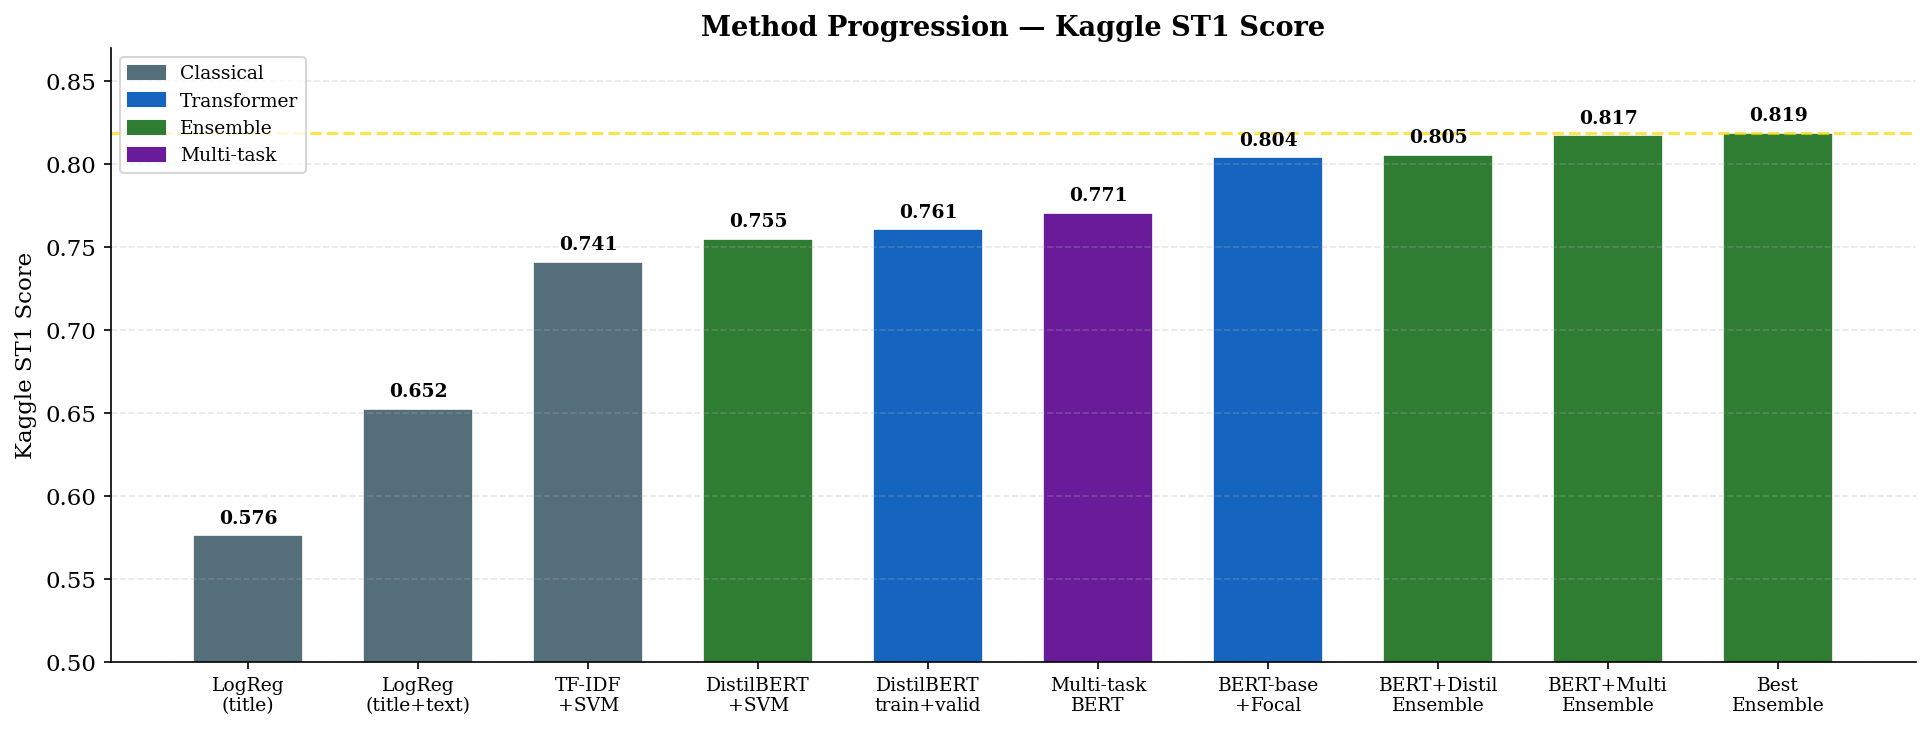

Saved: report_figures/method_progression.pdf


In [4]:
progression = [
    ('LogReg\n(title)', 'Classical', 0.5761),
    ('LogReg\n(title+text)', 'Classical', 0.6523),
    ('TF-IDF\n+SVM', 'Classical', 0.7408),
    ('DistilBERT\n+SVM', 'Ensemble', 0.7547),
    ('DistilBERT\ntrain+valid', 'Transformer', 0.7606),
    ('Multi-task\nBERT', 'Multi-task', 0.7706),
    ('BERT-base\n+Focal', 'Transformer', 0.8040),
    ('BERT+Distil\nEnsemble', 'Ensemble', 0.8055),
    ('BERT+Multi\nEnsemble', 'Ensemble', 0.8173),
    ('Best\nEnsemble', 'Ensemble', 0.8188),
]

cat_colors = {
    'Classical':    '#546E7A',
    'Transformer':  '#1565C0',
    'Ensemble':     '#2E7D32',
    'Multi-task':   '#6A1B9A',
}

labels  = [p[0] for p in progression]
cats    = [p[1] for p in progression]
scores  = [p[2] for p in progression]
colors  = [cat_colors[c] for c in cats]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(range(len(labels)), scores, color=colors, edgecolor='white', linewidth=0.8, width=0.65)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Kaggle ST1 Score')
ax.set_title('Method Progression — Kaggle ST1 Score', fontweight='bold')
ax.set_ylim(0.50, 0.87)
ax.axhline(y=0.8188, color='gold', linestyle='--', linewidth=1.5, alpha=0.7, label='Best: 0.8188')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in cat_colors.items()]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('report_figures/method_progression.pdf')
plt.savefig('report_figures/method_progression.png')
plt.show()
print('Saved: report_figures/method_progression.pdf')

## 3. Confusion Matrices — TF-IDF + SVM

TF-IDF + SVM validation ST1: 0.7436


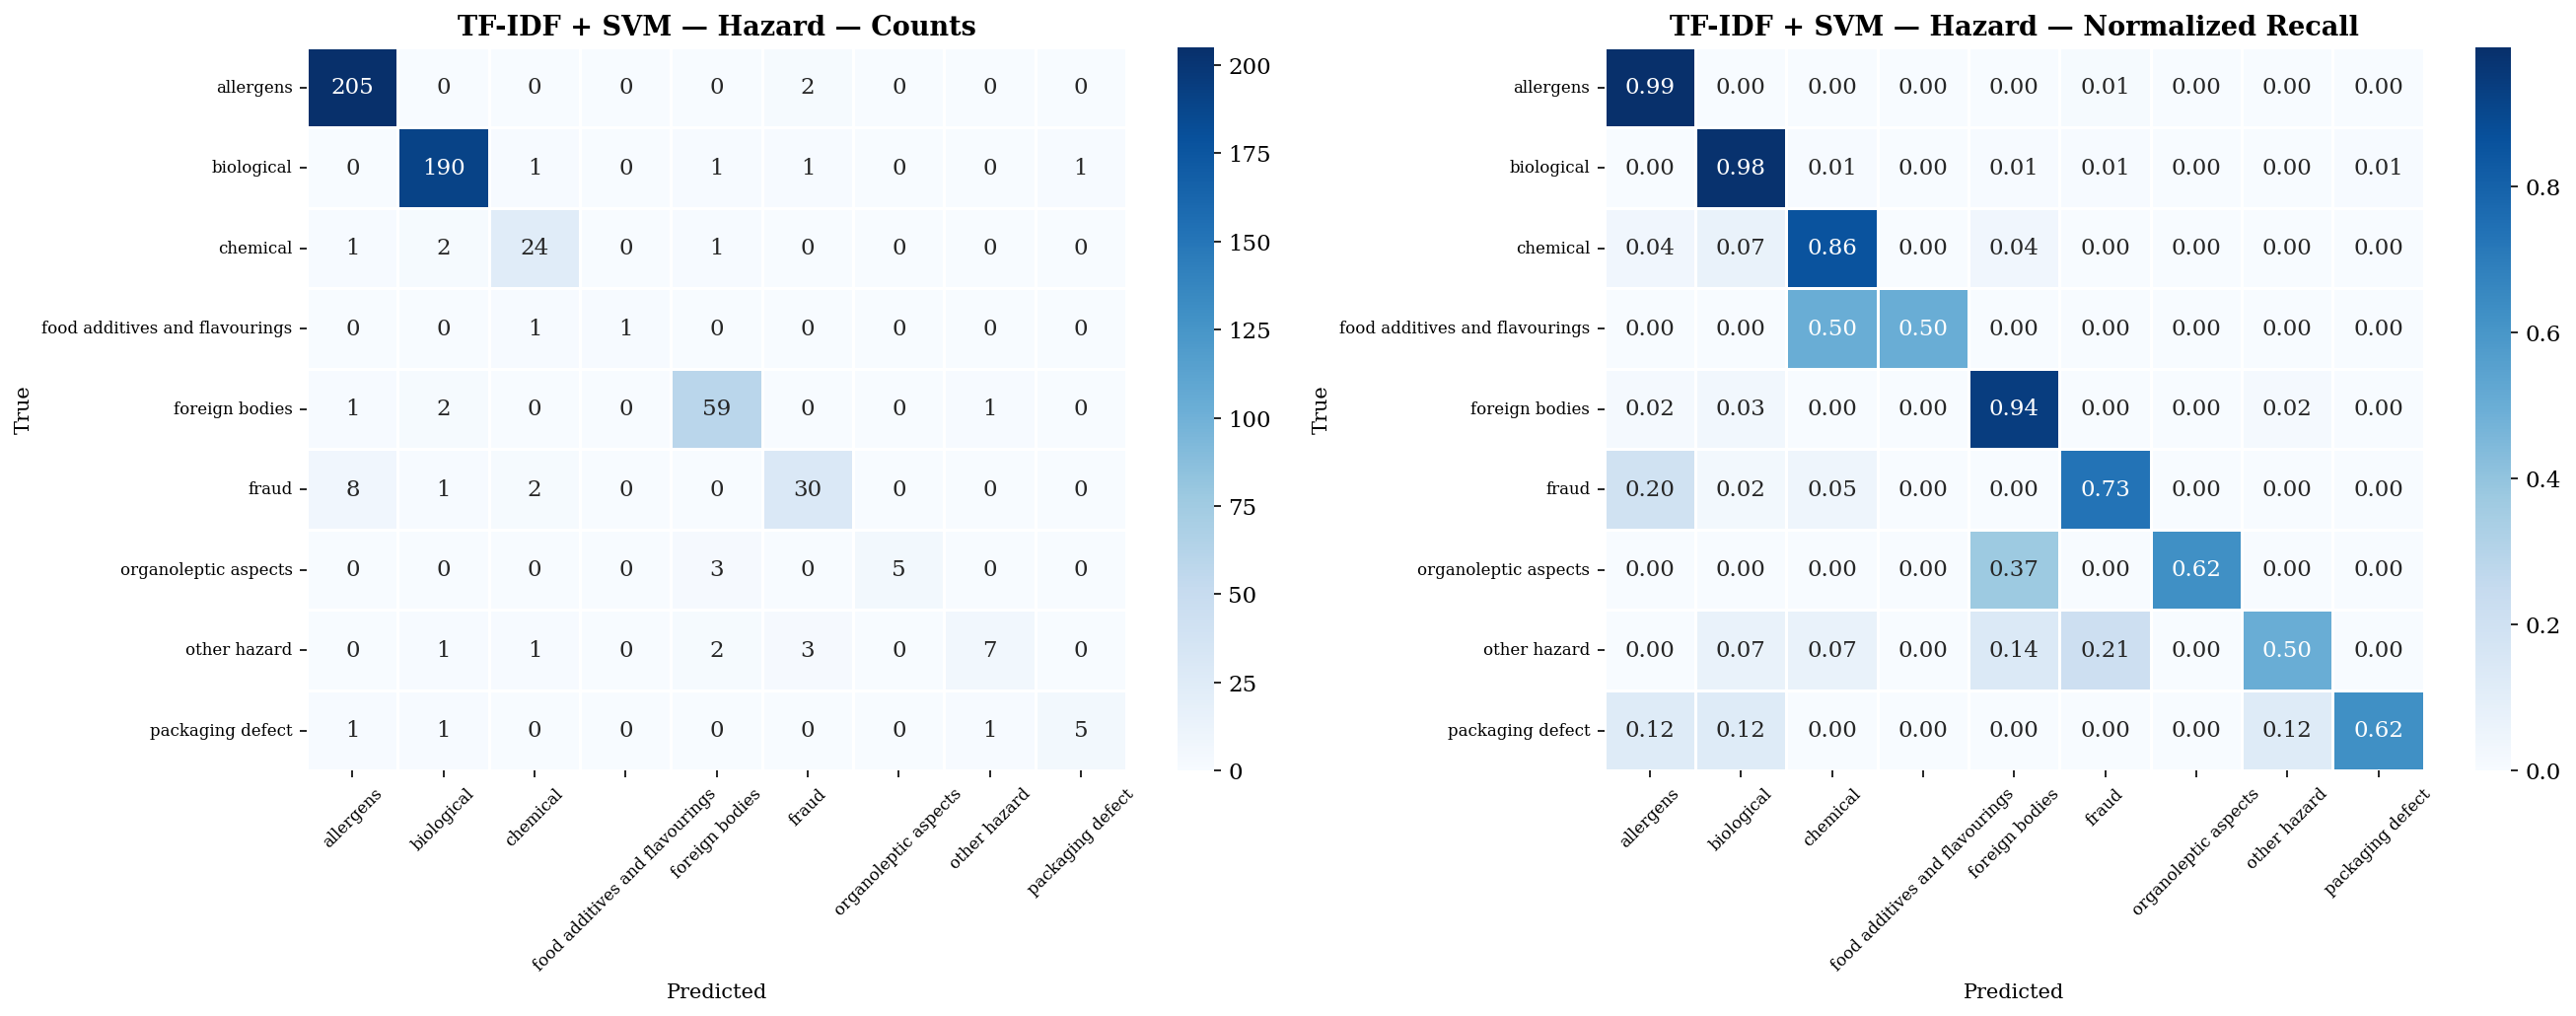

Saved: report_figures/cm_svm_hazard.pdf


In [5]:
# Train TF-IDF+SVM on train, evaluate on valid
train['combined'] = train['title'].apply(preprocess) + ' ' + train['text'].str[:550].apply(preprocess)
valid['combined'] = valid['title'].apply(preprocess) + ' ' + valid['text'].str[:550].apply(preprocess)

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2), sublinear_tf=True, stop_words='english')
X_train = tfidf.fit_transform(train['combined'])
X_valid = tfidf.transform(valid['combined'])

clf_h = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
clf_h.fit(X_train, train['hazard-category'])
clf_p = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
clf_p.fit(X_train, train['product-category'])

svm_pred_h = clf_h.predict(X_valid)
svm_pred_p = clf_p.predict(X_valid)

svm_score = official_st1_score(valid['hazard-category'], svm_pred_h,
                                valid['product-category'], svm_pred_p)
print(f'TF-IDF + SVM validation ST1: {svm_score:.4f}')


def plot_confusion_matrix(y_true, y_pred, labels, title, filename, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-6)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, data, fmt, ttl in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        [f'{title} — Counts', f'{title} — Normalized Recall']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                    xticklabels=labels, yticklabels=labels,
                    ax=ax, linewidths=0.5, linecolor='white')
        ax.set_title(ttl, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=10)
        ax.set_ylabel('True', fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', rotation=0, labelsize=8)

    plt.tight_layout()
    plt.savefig(f'report_figures/{filename}.pdf')
    plt.savefig(f'report_figures/{filename}.png')
    plt.show()
    print(f'Saved: report_figures/{filename}.pdf')


hazard_labels = sorted(valid['hazard-category'].unique())
plot_confusion_matrix(
    valid['hazard-category'], svm_pred_h,
    hazard_labels,
    'TF-IDF + SVM — Hazard',
    'cm_svm_hazard'
)

## 4. Confusion Matrices — BERT-base + Focal Loss

BERT-base + Focal Loss validation ST1: 0.4479


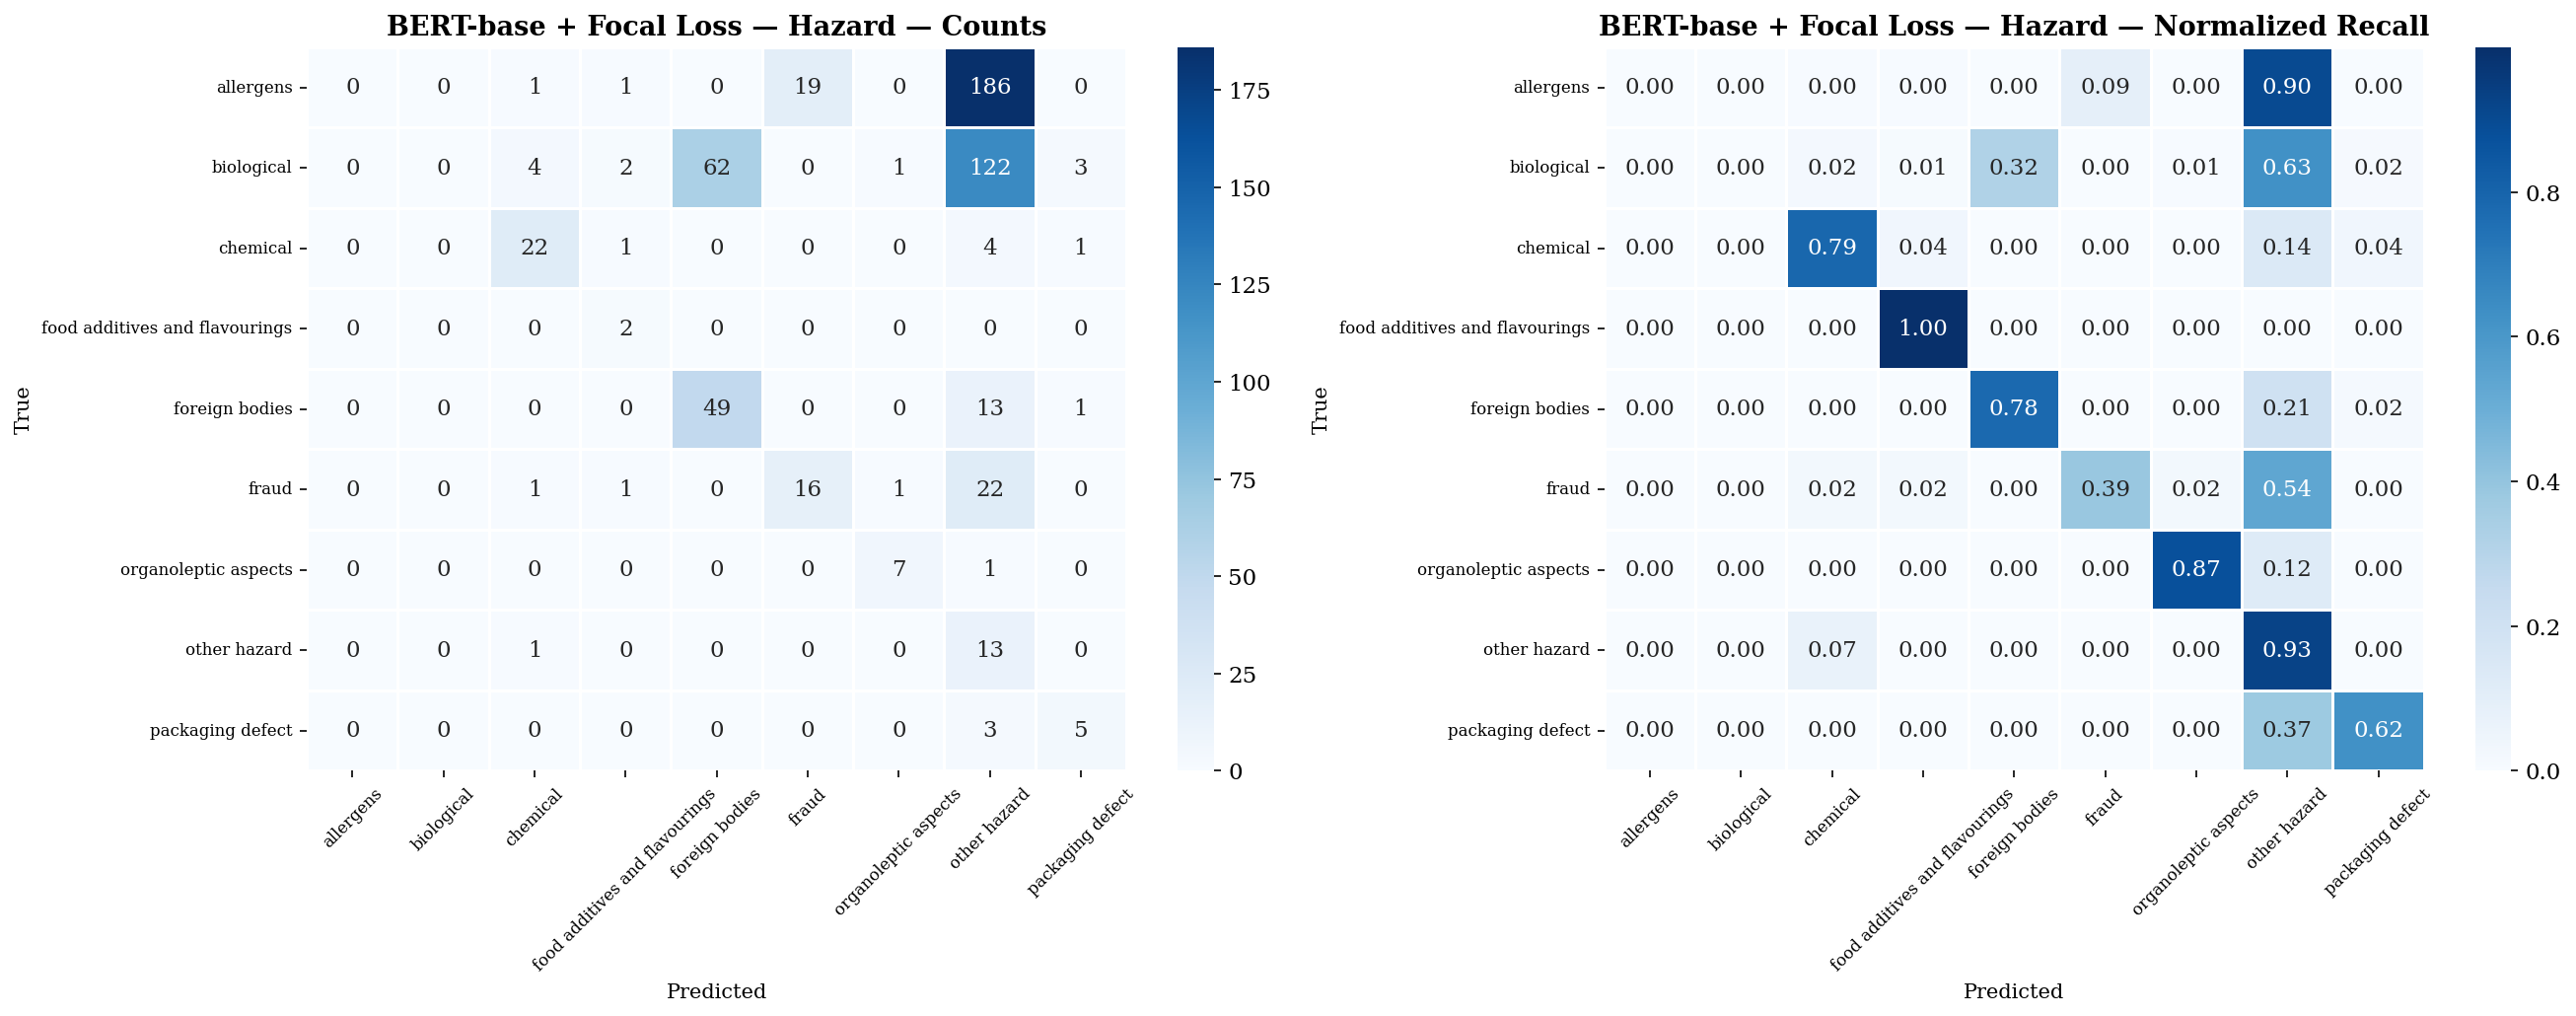

Saved: report_figures/cm_bert_hazard.pdf


In [7]:
# Φόρτωση BERT-base Focal valid probs (train-only model)
bert_valid_hazard_probs  = np.load('npy/bertbase_focal_trainonly_valid_hazard_probs.npy')
bert_valid_product_probs = np.load('npy/bertbase_focal_trainonly_valid_product_probs.npy')

bert_pred_h = le_hazard.inverse_transform(bert_valid_hazard_probs.argmax(axis=1))
bert_pred_p = le_product.inverse_transform(bert_valid_product_probs.argmax(axis=1))

bert_score = official_st1_score(valid['hazard-category'], bert_pred_h,
                                 valid['product-category'], bert_pred_p)
print(f'BERT-base + Focal Loss validation ST1: {bert_score:.4f}')

plot_confusion_matrix(
    valid['hazard-category'], bert_pred_h,
    hazard_labels,
    'BERT-base + Focal Loss — Hazard',
    'cm_bert_hazard'
)

## 5. Class-wise F1 Comparison

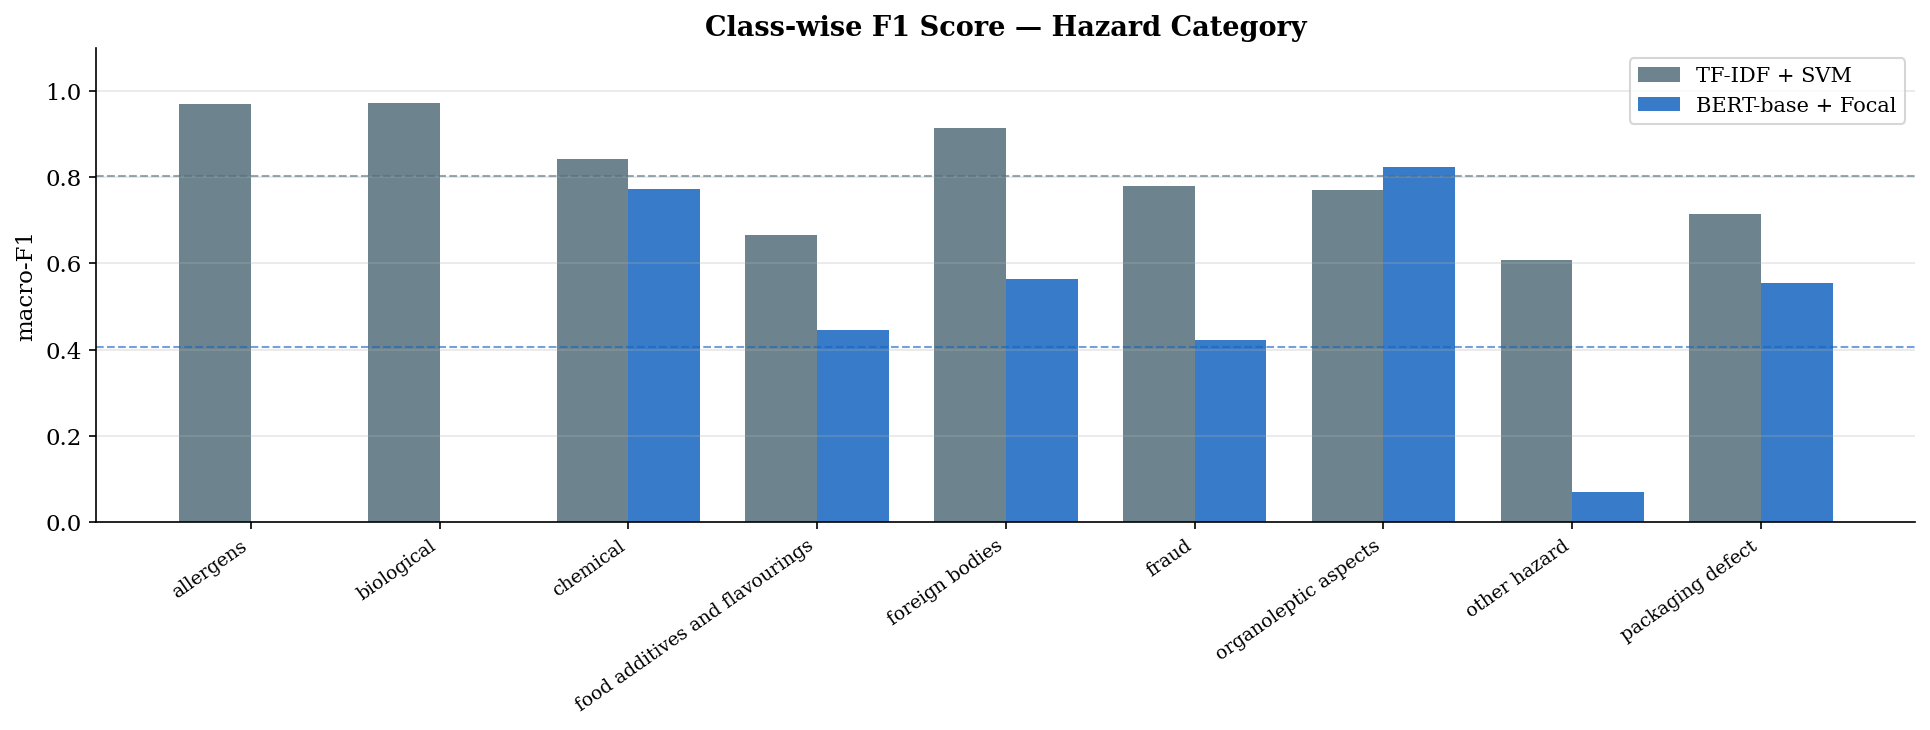

Saved: report_figures/classwise_f1_comparison.pdf

Class-wise F1 Comparison:
Class                          SVM      BERT     Δ       
-------------------------------------------------------
allergens                      0.969    0.000    -0.969  (n=207)
biological                     0.972    0.000    -0.972  (n=194)
chemical                       0.842    0.772    -0.070  (n=28)
food additives and flavourings 0.667    0.444    -0.222  (n=2)
foreign bodies                 0.915    0.563    -0.352  (n=63)
fraud                          0.779    0.421    -0.358  (n=41)
organoleptic aspects           0.769    0.824    +0.054  (n=8)
other hazard                   0.609    0.069    -0.540  (n=14)
packaging defect               0.714    0.556    -0.159  (n=8)


In [8]:
f1_svm  = f1_score(valid['hazard-category'], svm_pred_h,
                    labels=hazard_labels, average=None, zero_division=0)
f1_bert = f1_score(valid['hazard-category'], bert_pred_h,
                    labels=hazard_labels, average=None, zero_division=0)

x = np.arange(len(hazard_labels))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, f1_svm,  width, label='TF-IDF + SVM',        color='#546E7A', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_bert, width, label='BERT-base + Focal',   color='#1565C0', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(hazard_labels, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('macro-F1')
ax.set_title('Class-wise F1 Score — Hazard Category', fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)
ax.axhline(y=f1_svm.mean(),  color='#546E7A', linestyle='--', linewidth=1, alpha=0.6, label=f'SVM mean={f1_svm.mean():.3f}')
ax.axhline(y=f1_bert.mean(), color='#1565C0', linestyle='--', linewidth=1, alpha=0.6, label=f'BERT mean={f1_bert.mean():.3f}')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('report_figures/classwise_f1_comparison.pdf')
plt.savefig('report_figures/classwise_f1_comparison.png')
plt.show()
print('Saved: report_figures/classwise_f1_comparison.pdf')

# Print table
print('\nClass-wise F1 Comparison:')
print(f'{"Class":30s} {"SVM":8s} {"BERT":8s} {"Δ":8s}')
print('-' * 55)
counts = valid['hazard-category'].value_counts()
for cls, f_svm, f_bert in zip(hazard_labels, f1_svm, f1_bert):
    n = counts.get(cls, 0)
    print(f'{cls:30s} {f_svm:.3f}    {f_bert:.3f}    {f_bert-f_svm:+.3f}  (n={n})')

## 6. Ablation Study — Text Input

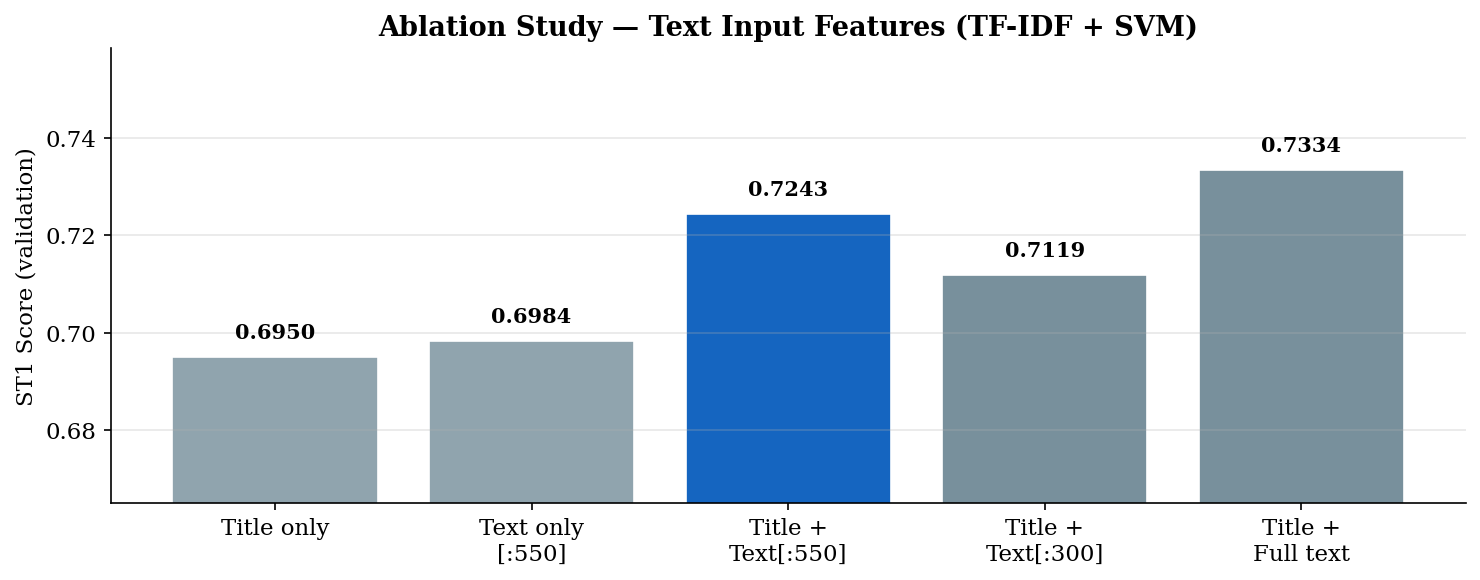

Saved: report_figures/ablation_text_input.pdf

Ablation results:
  Title only               : 0.6950
  Text only [:550]         : 0.6984
  Title + Text[:550]       : 0.7243
  Title + Text[:300]       : 0.7119
  Title + Full text        : 0.7334


In [9]:
def run_svm(train_texts, valid_texts):
    tfidf_tmp = TfidfVectorizer(max_features=50000, ngram_range=(1,2),
                                 sublinear_tf=True, stop_words='english')
    X_tr = tfidf_tmp.fit_transform(train_texts)
    X_va = tfidf_tmp.transform(valid_texts)
    clf_h_tmp = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
    clf_h_tmp.fit(X_tr, train['hazard-category'])
    clf_p_tmp = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
    clf_p_tmp.fit(X_tr, train['product-category'])
    return official_st1_score(
        valid['hazard-category'], clf_h_tmp.predict(X_va),
        valid['product-category'], clf_p_tmp.predict(X_va)
    )

ablation_results = {
    'Title only':         run_svm(train['title'].fillna(''), valid['title'].fillna('')),
    'Text only\n[:550]':  run_svm(train['text'].fillna('').str[:550], valid['text'].fillna('').str[:550]),
    'Title +\nText[:550]': run_svm(
        train['title'].fillna('') + ' ' + train['text'].fillna('').str[:550],
        valid['title'].fillna('') + ' ' + valid['text'].fillna('').str[:550]
    ),
    'Title +\nText[:300]': run_svm(
        train['title'].fillna('') + ' ' + train['text'].fillna('').str[:300],
        valid['title'].fillna('') + ' ' + valid['text'].fillna('').str[:300]
    ),
    'Title +\nFull text': run_svm(
        train['title'].fillna('') + ' ' + train['text'].fillna(''),
        valid['title'].fillna('') + ' ' + valid['text'].fillna('')
    ),
}

fig, ax = plt.subplots(figsize=(10, 4))
colors_abl = ['#90A4AE', '#90A4AE', '#1565C0', '#78909C', '#78909C']
bars = ax.bar(ablation_results.keys(), ablation_results.values(),
               color=colors_abl, edgecolor='white', linewidth=0.8)

for bar, score in zip(bars, ablation_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{score:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('ST1 Score (validation)')
ax.set_title('Ablation Study — Text Input Features (TF-IDF + SVM)', fontweight='bold')
ax.set_ylim(min(ablation_results.values()) - 0.03, max(ablation_results.values()) + 0.025)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('report_figures/ablation_text_input.pdf')
plt.savefig('report_figures/ablation_text_input.png')
plt.show()
print('Saved: report_figures/ablation_text_input.pdf')
print('\nAblation results:')
for k, v in ablation_results.items():
    print(f'  {k.replace(chr(10)," "):25s}: {v:.4f}')

## 7. Dataset Analysis — Class Distribution

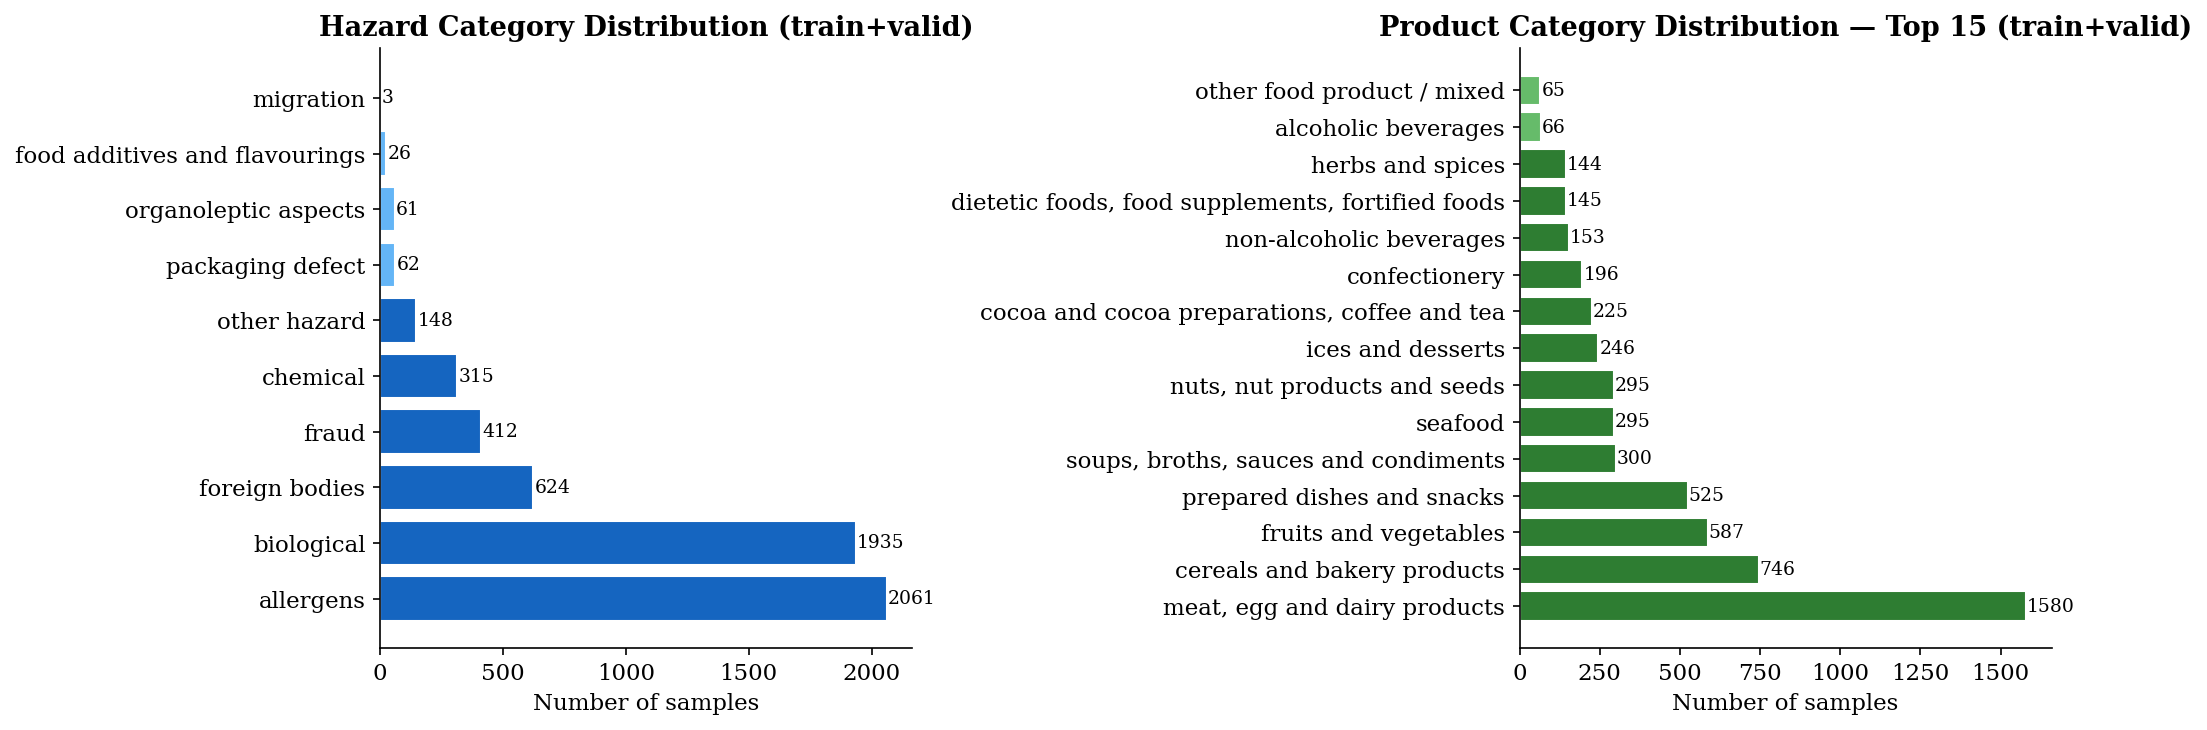

Saved: report_figures/class_distribution.pdf


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hazard distribution
hazard_counts = train_full['hazard-category'].value_counts()
colors_h = ['#1565C0' if c > 100 else '#64B5F6' if c > 20 else '#EF9A9A'
            for c in hazard_counts.values]
axes[0].barh(hazard_counts.index, hazard_counts.values, color=colors_h, edgecolor='white')
axes[0].set_xlabel('Number of samples')
axes[0].set_title('Hazard Category Distribution (train+valid)', fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for i, (v, c) in enumerate(zip(hazard_counts.values, hazard_counts.index)):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# Product distribution (top 15)
product_counts = train_full['product-category'].value_counts().head(15)
colors_p = ['#2E7D32' if c > 100 else '#66BB6A' if c > 30 else '#EF9A9A'
            for c in product_counts.values]
axes[1].barh(product_counts.index, product_counts.values, color=colors_p, edgecolor='white')
axes[1].set_xlabel('Number of samples')
axes[1].set_title('Product Category Distribution — Top 15 (train+valid)', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, v in enumerate(product_counts.values):
    axes[1].text(v + 3, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('report_figures/class_distribution.pdf')
plt.savefig('report_figures/class_distribution.png')
plt.show()
print('Saved: report_figures/class_distribution.pdf')

## 8. Confidence Analysis

Mean confidence (correct):   0.467
Mean confidence (incorrect): 0.377


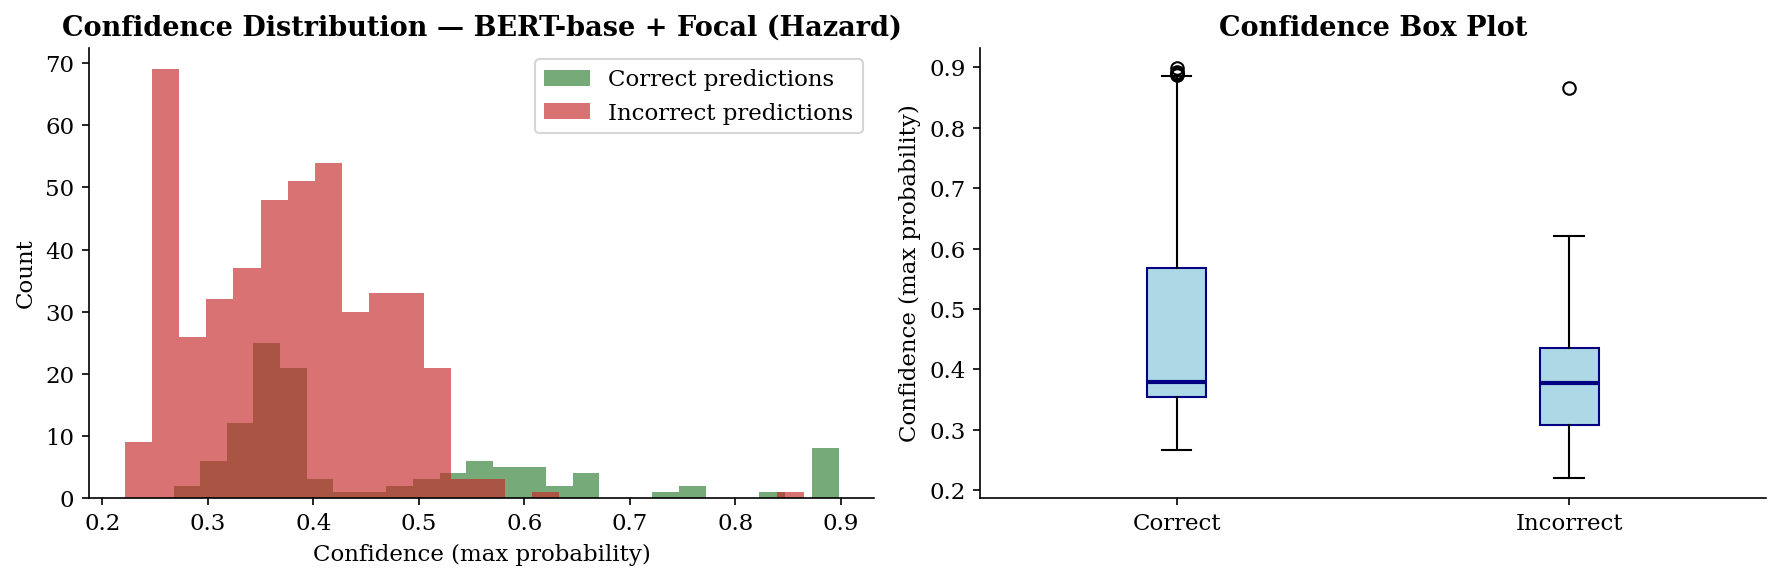

Saved: report_figures/confidence_analysis.pdf


In [11]:
max_probs = bert_valid_hazard_probs.max(axis=1)
correct_mask = (valid['hazard-category'].values == bert_pred_h)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(max_probs[correct_mask],  bins=25, alpha=0.65, label='Correct predictions',   color='#2E7D32')
axes[0].hist(max_probs[~correct_mask], bins=25, alpha=0.65, label='Incorrect predictions', color='#C62828')
axes[0].set_xlabel('Confidence (max probability)')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution — BERT-base + Focal (Hazard)', fontweight='bold')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Box plot
axes[1].boxplot(
    [max_probs[correct_mask], max_probs[~correct_mask]],
    labels=['Correct', 'Incorrect'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='navy'),
    medianprops=dict(color='navy', linewidth=2)
)
axes[1].set_ylabel('Confidence (max probability)')
axes[1].set_title('Confidence Box Plot', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

print(f'Mean confidence (correct):   {max_probs[correct_mask].mean():.3f}')
print(f'Mean confidence (incorrect): {max_probs[~correct_mask].mean():.3f}')

plt.tight_layout()
plt.savefig('report_figures/confidence_analysis.pdf')
plt.savefig('report_figures/confidence_analysis.png')
plt.show()
print('Saved: report_figures/confidence_analysis.pdf')

## 9. Category Comparison: Classical vs Neural

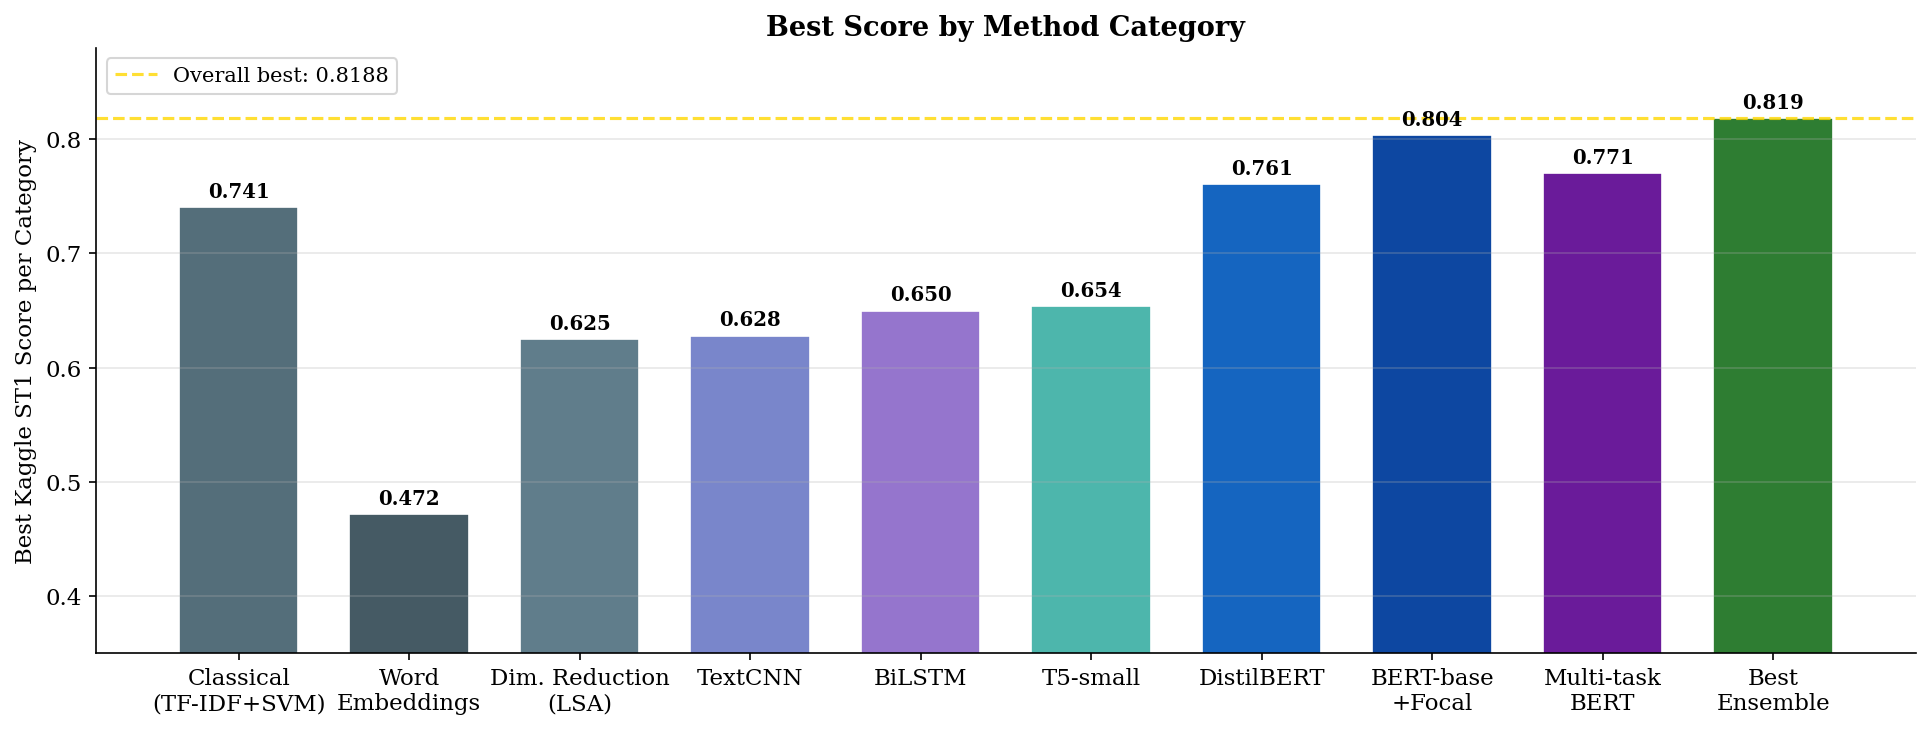

Saved: report_figures/category_comparison.pdf


In [12]:
# Group by category
category_best = {
    'Classical\n(TF-IDF+SVM)':     0.7408,
    'Word\nEmbeddings':             0.4716,
    'Dim. Reduction\n(LSA)':       0.6252,
    'TextCNN':                      0.6280,
    'BiLSTM':                       0.6500,
    'T5-small':                     0.6540,
    'DistilBERT':                   0.7606,
    'BERT-base\n+Focal':           0.8040,
    'Multi-task\nBERT':            0.7706,
    'Best\nEnsemble':              0.8188,
}

cat_palette = [
    '#546E7A', '#455A64', '#607D8B',  # Classical variants
    '#7986CB', '#9575CD', '#4DB6AC',  # Neural
    '#1565C0', '#0D47A1',              # Transformers
    '#6A1B9A',                         # Multi-task
    '#2E7D32',                         # Ensemble
]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(category_best.keys(), category_best.values(),
               color=cat_palette, edgecolor='white', linewidth=0.8, width=0.7)

for bar, score in zip(bars, category_best.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.3f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax.set_ylabel('Best Kaggle ST1 Score per Category')
ax.set_title('Best Score by Method Category', fontweight='bold')
ax.set_ylim(0.35, 0.88)
ax.axhline(y=0.8188, color='gold', linestyle='--', linewidth=1.5, alpha=0.8, label='Overall best: 0.8188')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('report_figures/category_comparison.pdf')
plt.savefig('report_figures/category_comparison.png')
plt.show()
print('Saved: report_figures/category_comparison.pdf')

## 10. Summary of All Saved Figures

In [13]:
import glob
figures = sorted(glob.glob('report_figures/*.pdf'))
print('=== FIGURES SAVED FOR REPORT ===')
for f in figures:
    print(f'  {f}')

print(f'\nTotal: {len(figures)} PDF figures')
print('\nLaTeX usage example:')
print(r'\includegraphics[width=\linewidth]{report_figures/method_progression.pdf}')

=== FIGURES SAVED FOR REPORT ===
  report_figures\ablation_text_input.pdf
  report_figures\category_comparison.pdf
  report_figures\class_distribution.pdf
  report_figures\classwise_f1_comparison.pdf
  report_figures\cm_bert_hazard.pdf
  report_figures\cm_svm_hazard.pdf
  report_figures\confidence_analysis.pdf
  report_figures\method_progression.pdf

Total: 8 PDF figures

LaTeX usage example:
\includegraphics[width=\linewidth]{report_figures/method_progression.pdf}
